In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Figure 9.5-3 &mdash; the one-constant Margules activity coefficients

This notebook reproduces **Figure 9.5-3**: the activity coefficients of the
one-constant Margules equation at $A/RT = 1$.

Like Fig. 6.6-1 for the van der Waals equation, this figure carries **no substance
name and no temperature**. Everything depends on the single group $A/RT$, so the
curves are the same for every mixture the model describes &mdash; which is exactly
what makes the model easy to use and, as the next two figures show, easy to
outgrow.

The figure is one curve pair. What a notebook can add is the reason the pair looks
the way it does, and what that shape *costs*: the two curves are mirror images, and
real mixtures are not symmetric.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

## The model

$$\underline{G}^{\rm ex} = A x_1 x_2
\qquad RT\ln\gamma_1 = A x_2^2
\qquad RT\ln\gamma_2 = A x_1^2
\tag{Eqs. 9.5-1, 9.5-5}$$

One constant, and it enters only as the dimensionless group $A/RT$. The printed
figure fixes $A/RT = 1$, so $A = RT$ at whatever temperature you like &mdash; the
curves do not move.

**Sign convention (SIS p. 449):** $A > 0$ gives $\gamma_i > 1$, positive
deviations from ideality; $A < 0$ gives $\gamma_i < 1$. Figure 9.5-3 shows the
positive case.

In [3]:
from thermo import OneConstantMargules

T = 300.0                      # arbitrary -- only A/RT matters
A_over_RT = 1.0
m = OneConstantMargules(A_over_RT * R * T)

x1 = np.linspace(0, 1, 400)
g = np.array([m.gamma([a, 1 - a], T) for a in x1])
g1, g2 = g[:, 0], g[:, 1]

print(f"A/RT = {A_over_RT}  ->  A = {m.A:.1f} J/mol at T = {T:.0f} K")
print(f"gamma_1 at x1 = 0 : {g1[0]:.4f}      exp(A/RT) = {np.exp(A_over_RT):.4f}")
print(f"gamma_2 at x1 = 1 : {g2[-1]:.4f}      exp(A/RT) = {np.exp(A_over_RT):.4f}")
print(f"Gibbs-Duhem residual: {m.check_gibbs_duhem(T):.1e}")

A/RT = 1.0  ->  A = 2494.3 J/mol at T = 300 K
gamma_1 at x1 = 0 : 2.7183      exp(A/RT) = 2.7183
gamma_2 at x1 = 1 : 2.7183      exp(A/RT) = 2.7183
Gibbs-Duhem residual: 5.6e-17


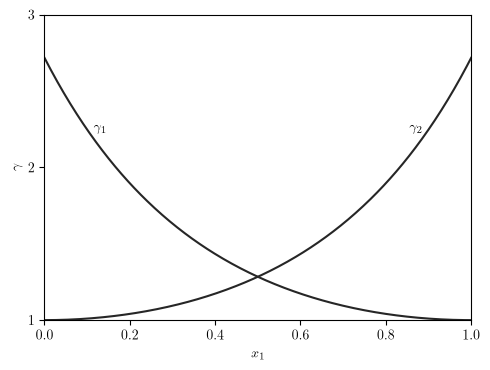

In [4]:
fig, ax = plt.subplots(figsize=(5.0, 3.8))
ax.plot(x1, g1, "-", color="0.15")
ax.plot(x1, g2, "-", color="0.15")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$\gamma$")
ax.set_xlim(0, 1); ax.set_ylim(1, 3)
# Integer ordinate ticks, as the printed figure has them -- gamma spans a single
# factor of e, so 1/2/3 is all the scale a reader needs.
ax.yaxis.set_major_locator(MultipleLocator(1))

# Labels sit on their own curves, as the printed figure has them.
ax.text(0.13, np.interp(0.13, x1, g1) + 0.09, r"$\gamma_1$", ha="center", va="bottom")
ax.text(0.87, np.interp(0.87, x1, g2) + 0.09, r"$\gamma_2$", ha="center", va="bottom")
fig.tight_layout()

In [5]:
# --- Print art: Figure 9.5-3 -----------------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f004.pdf
#
# Drawn to the printed figure's own conventions, checked against the published art
# (c09f004.jpg): ordinate is GAMMA, not ln(gamma), running 1 to 3; abscissa is
# x_1; the curves are labeled on the curves as gamma_1 and gamma_2; no legend and
# no data points -- this figure is the model's shape, not a fit to anything.
#
# The gamma ordinate is deliberate and is the book's own choice. Figs. 9.5-4,
# 9.5-5, 9.6-1 and 9.6-2 all use ln(gamma) because they compare a model against
# data; 9.5-3 has no data and gamma runs over a single factor of e, so gamma reads
# more naturally. Do not "correct" this one to match the others.
import os
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_9.5-3.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_9.5-3.pdf")

wrote pdf/Fig_9.5-3.pdf


## What the shape costs

The two curves are **mirror images** &mdash; $\gamma_2(x_1) = \gamma_1(1-x_1)$
&mdash; and that is not a fact about mixtures. It follows from choosing a
$\underline{G}^{\rm ex}$ that is symmetric in the mole fractions. One constant cannot
do anything else.

In [6]:
print("mirror symmetry, gamma_2(x1) vs gamma_1(1-x1):")
print(f"  max |difference| over the composition range: "
      f"{np.abs(g2 - np.interp(1 - x1, x1, g1)).max():.2e}")

print("\ninfinite-dilution values -- the model forces them equal:")
for AoRT in (0.2, 0.5, 1.0, 2.0):
    mk = OneConstantMargules(AoRT * R * T)
    inf1 = mk.gamma([1e-12, 1 - 1e-12], T)[0]
    inf2 = mk.gamma([1 - 1e-12, 1e-12], T)[1]
    print(f"  A/RT = {AoRT:4.1f}   gamma_1^inf = {inf1:6.3f}   gamma_2^inf = {inf2:6.3f}"
          f"   exp(A/RT) = {np.exp(AoRT):6.3f}")

mirror symmetry, gamma_2(x1) vs gamma_1(1-x1):
  max |difference| over the composition range: 8.88e-16

infinite-dilution values -- the model forces them equal:
  A/RT =  0.2   gamma_1^inf =  1.221   gamma_2^inf =  1.221   exp(A/RT) =  1.221
  A/RT =  0.5   gamma_1^inf =  1.649   gamma_2^inf =  1.649   exp(A/RT) =  1.649
  A/RT =  1.0   gamma_1^inf =  2.718   gamma_2^inf =  2.718   exp(A/RT) =  2.718
  A/RT =  2.0   gamma_1^inf =  7.389   gamma_2^inf =  7.389   exp(A/RT) =  7.389


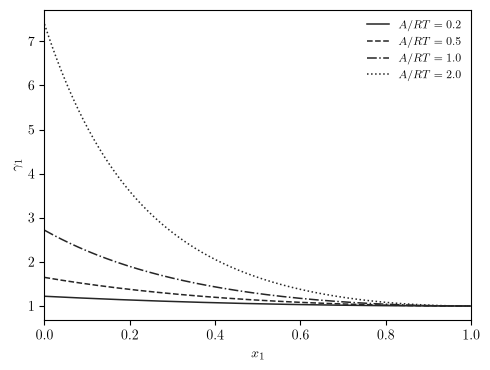

In [7]:
fig2, ax2 = plt.subplots(figsize=(5.0, 3.8))
for AoRT, ls in zip((0.2, 0.5, 1.0, 2.0), ("-", "--", "-.", ":")):
    mk = OneConstantMargules(AoRT * R * T)
    gk = np.array([mk.gamma([a, 1 - a], T) for a in x1])
    ax2.plot(x1, gk[:, 0], ls=ls, color="0.15", lw=1.1, label=rf"$A/RT = {AoRT}$")
ax2.set_xlabel(r"$x_1$"); ax2.set_ylabel(r"$\gamma_1$")
ax2.set_xlim(0, 1); ax2.legend(frameon=False, fontsize=8)
fig2.tight_layout()

**$A/RT$ sets the size of the deviation and nothing else.** Every curve leaves
$\gamma_1 = \exp(A/RT)$ at infinite dilution and arrives at 1 in the pure limit, with
the same shape in between. There is no way to make the two species differ.

**That is the whole reason Figure 9.5-4 exists.** Illustration 9.5-1 fits this
model to benzene / 2,2,4-trimethyl pentane, where $\gamma_{\rm TMP}^\infty$ is about
1.97 and $\gamma_{\rm B}^\infty$ about 1.5 &mdash; two numbers this model is
structurally unable to produce at once. The van Laar equations of Fig. 9.5-5 are the
first model in the chapter that can.

- [`activity_coefficient_correlation_benzene_TMP_example.ipynb`](activity_coefficient_correlation_benzene_TMP_example.ipynb)
  &mdash; this model and van Laar, fitted to real data (Illustration 9.5-1).

**Your turn.** Set $A/RT$ negative and redraw. Which way do the curves go, and what
kind of mixture does that describe? Section 9.11's tables name several classes &mdash;
find one and check whether its measured $\gamma$'s really are below 1.